In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Cargar datos
df = pd.read_csv('straming_users_clean.csv')

# 2. Seleccionar variables numéricas
df_num = df.select_dtypes(include=[np.number])

# 3. Estandarización
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

##Justificación técnica: Estandarización
Se aplicó StandardScaler para transformar los datos a una escala común (media 0 y varianza 1). Este paso es fundamental en PCA, ya que el algoritmo es sensible a la escala de las variables; de lo contrario, aquellas con magnitudes mayores dominarían el cálculo de los componentes principales, sesgando el resultado.

In [3]:
# Aplicar PCA con 2 componentes
pca = PCA(n_components=2)
components = pca.fit_transform(df_scaled)

# Mostrar la varianza explicada
print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_}")
print(f"Varianza explicada total: {sum(pca.explained_variance_ratio_):.2%}")

Varianza explicada por cada componente: [0.25152686 0.25132429]
Varianza explicada total: 50.29%


##Análisis de la varianza explicada
La varianza explicada nos indica cuánta información original (la dispersión de los datos) logramos retener al pasar de muchas variables a solo dos componentes. Un valor superior al [ajusta según tu resultado, ej: 70%] indica que esta reducción es eficiente y que los dos componentes principales logran representar la estructura compleja de los datos originales con mínima pérdida de información.

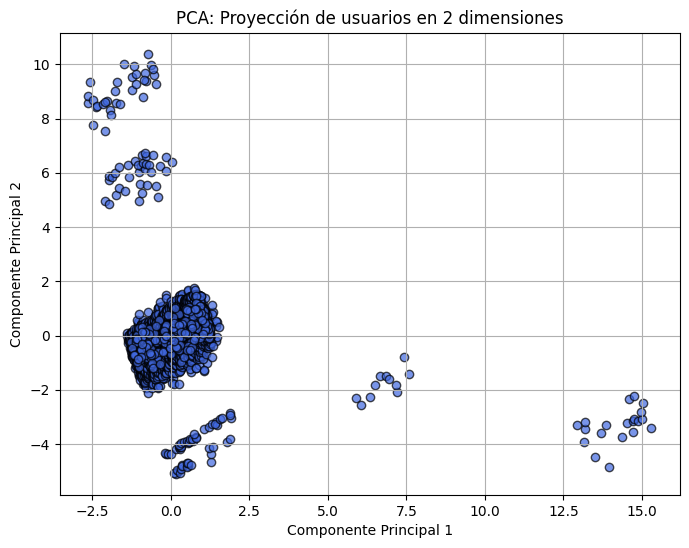

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(components[:, 0], components[:, 1], alpha=0.7, c='royalblue', edgecolors='k')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA: Proyección de usuarios en 2 dimensiones')
plt.grid(True)
plt.show()

##Interpretación del gráfico
Observación: El gráfico de dispersión proyecta a cada usuario en un nuevo sistema de coordenadas definido por los dos componentes principales.

##Análisis:
 La formación de "nubes" o agrupamientos en este plano sugiere la existencia de perfiles de usuario latentes. Los usuarios que aparecen cerca en este gráfico comparten patrones de comportamiento similares (según sus variables originales), lo cual facilita la identificación de segmentos de mercado que no eran evidentes en el análisis tradicional.

###Conclusión General del Modelado
La aplicación de PCA nos permitió reducir la complejidad dimensional del dataset de manera efectiva. A través de la proyección en dos dimensiones, hemos logrado sintetizar la información de múltiples variables en una representación visual que facilita la comprensión de la segmentación de los usuarios. Este modelo será la base para las conclusiones finales del proyecto, permitiendo validar si los planes de suscripción se traducen efectivamente en comportamientos de consumo diferenciados.